In [1]:
PATH_WORK_DIR = ".."

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M2-PJT_STATS


# package

In [4]:
import numpy as np
import pandas as pd
import arviz as az

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Data

In [6]:
PATH = './data/housing.csv'
df = pd.read_csv(PATH)

In [7]:
df["YEARMONTH"] = pd.to_datetime(
    df["YEARMONTH"].astype(str),
    format="%Y-%m",
)

In [ ]:
PATH = "./checkpoints/trace.nc"
trace = az.from_netcdf(PATH)

# Convergence Check

In [35]:
summary = az.summary(trace)

In [ ]:
COND1 = summary["ess_bulk"]<400
COND2 = summary["ess_tail"]<400
COND3 = summary["r_hat"]>1.01
COND4 = summary.index.str.contains("tau_raw")
summary[(COND1 | COND2 | COND3) & (~COND4)]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


# Eveluation

In [38]:
loo = az.loo(data=trace, pointwise=True)
print(loo)

Computed from 40000 posterior samples and 4414 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  4544.20   127.70
p_loo      138.09        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     4413  100.0%
   (0.70, 1]   (bad)         1    0.0%
   (1, Inf)   (very bad)    0    0.0%



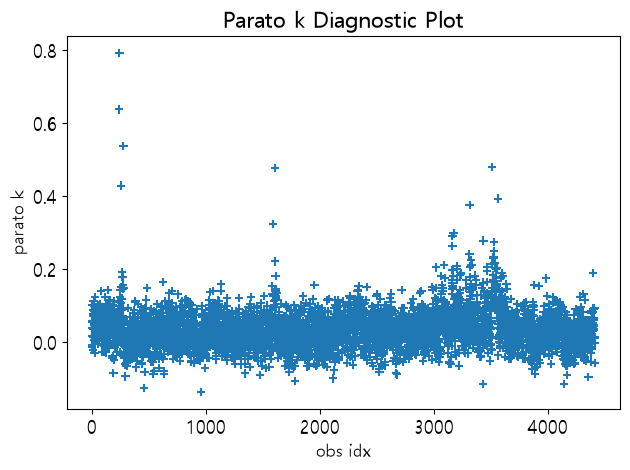

In [39]:
az.plot_khat(loo)

plt.xlabel("obs idx", fontsize=12)
plt.ylabel("parato k", fontsize=12)
plt.title("Parato k Diagnostic Plot", fontsize=16)

plt.tight_layout()
plt.show()

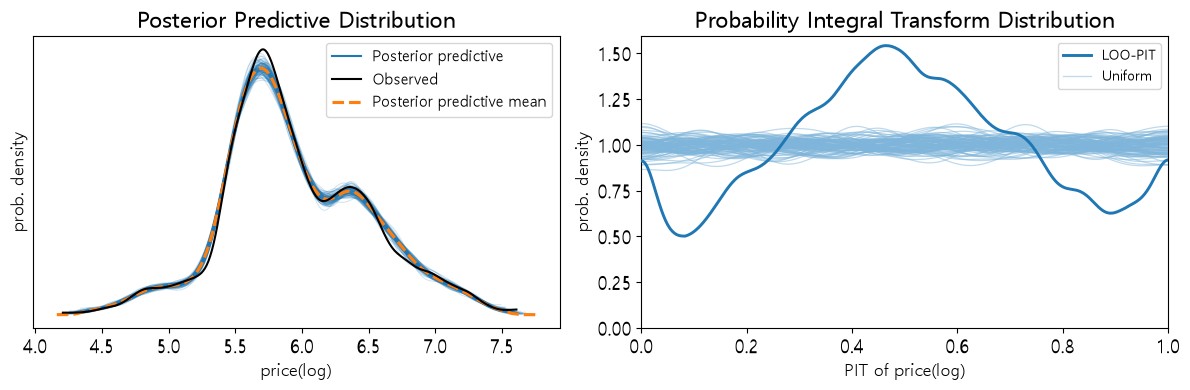

In [40]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(6*2, 4),
)

axes = axes.flatten()

az.plot_ppc(
    data=trace,
    num_pp_samples=100,
    ax=axes[0]
)

axes[0].set_xlabel("price(log)", fontsize=12)
axes[0].set_ylabel("prob. density", fontsize=12)
axes[0].set_title("Posterior Predictive Distribution", fontsize=16)

az.plot_loo_pit(
    idata=trace, 
    y="obs",
    ax=axes[1],
)

axes[1].set_xlabel("PIT of price(log)", fontsize=12)
axes[1].set_ylabel("prob. density", fontsize=12)
axes[1].set_title("Probability Integral Transform Distribution", fontsize=16)

plt.tight_layout()
plt.show()

# Fixed Effect: Area

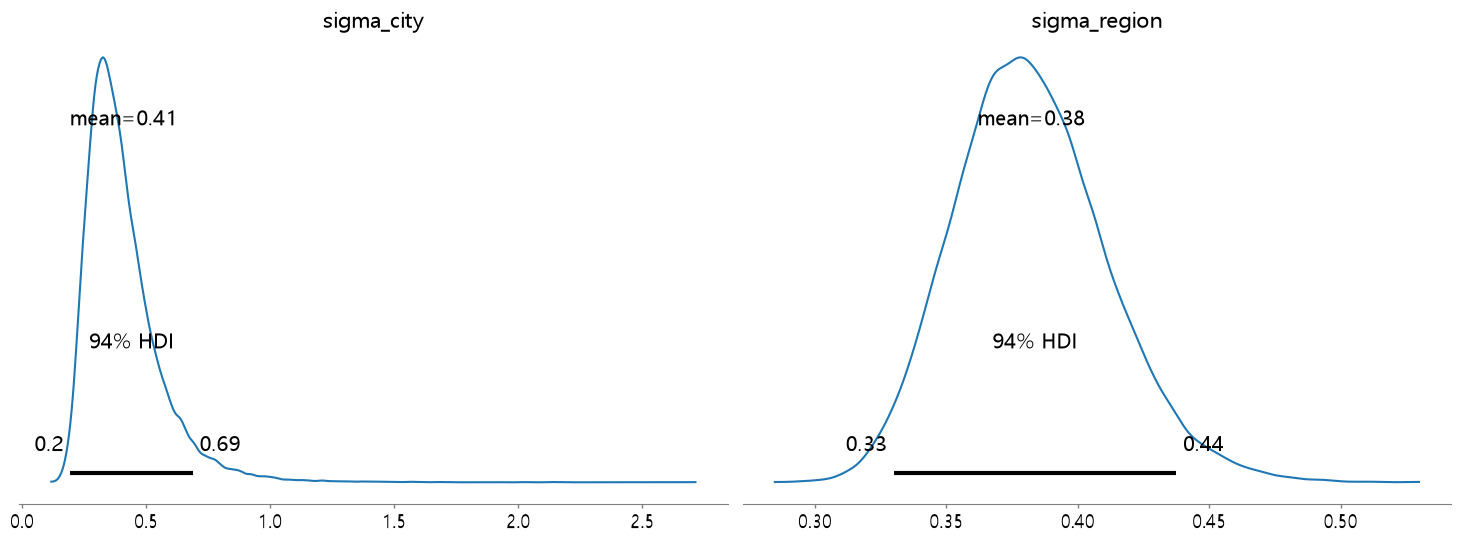

In [41]:
az.plot_posterior(
    data=trace, 
    var_names=["sigma_city", "sigma_region"],
)
plt.tight_layout()
plt.show()

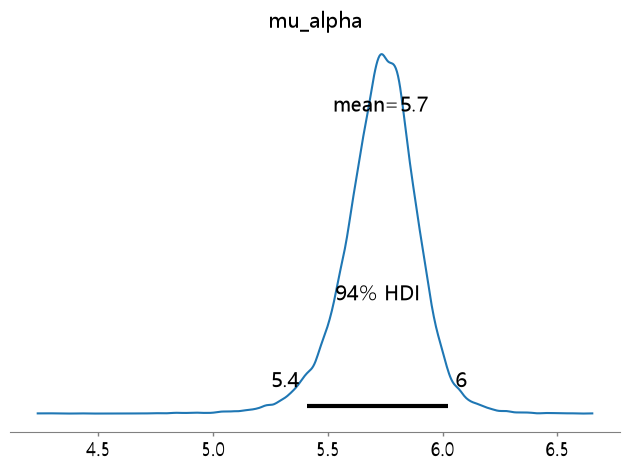

In [42]:
az.plot_posterior(
    data=trace, 
    var_names=["mu_alpha"],
)
plt.tight_layout()
plt.show()

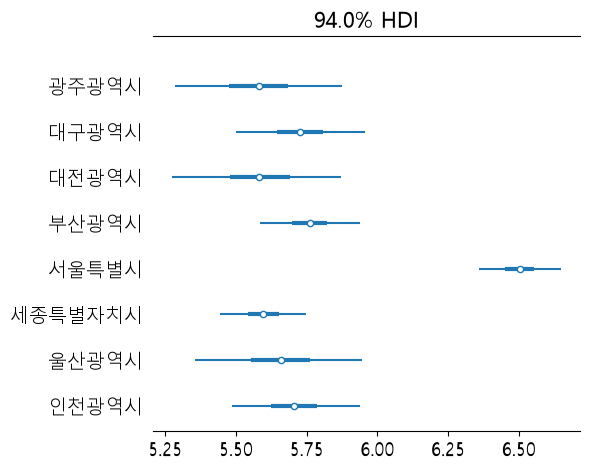

In [43]:
city_names = (
    df
    .drop_duplicates('CITY_IDX')
    .set_index('CITY_IDX')['CITY']
    .sort_index()
    .to_dict()
)
city_names = list(city_names.values())

az.plot_forest(
    data=trace, 
    var_names=["alpha_city"], 
    combined=True,
)
plt.yticks(
    ticks=plt.gca().get_yticks(),
    labels=city_names[::-1],
)
plt.tight_layout()
plt.show()

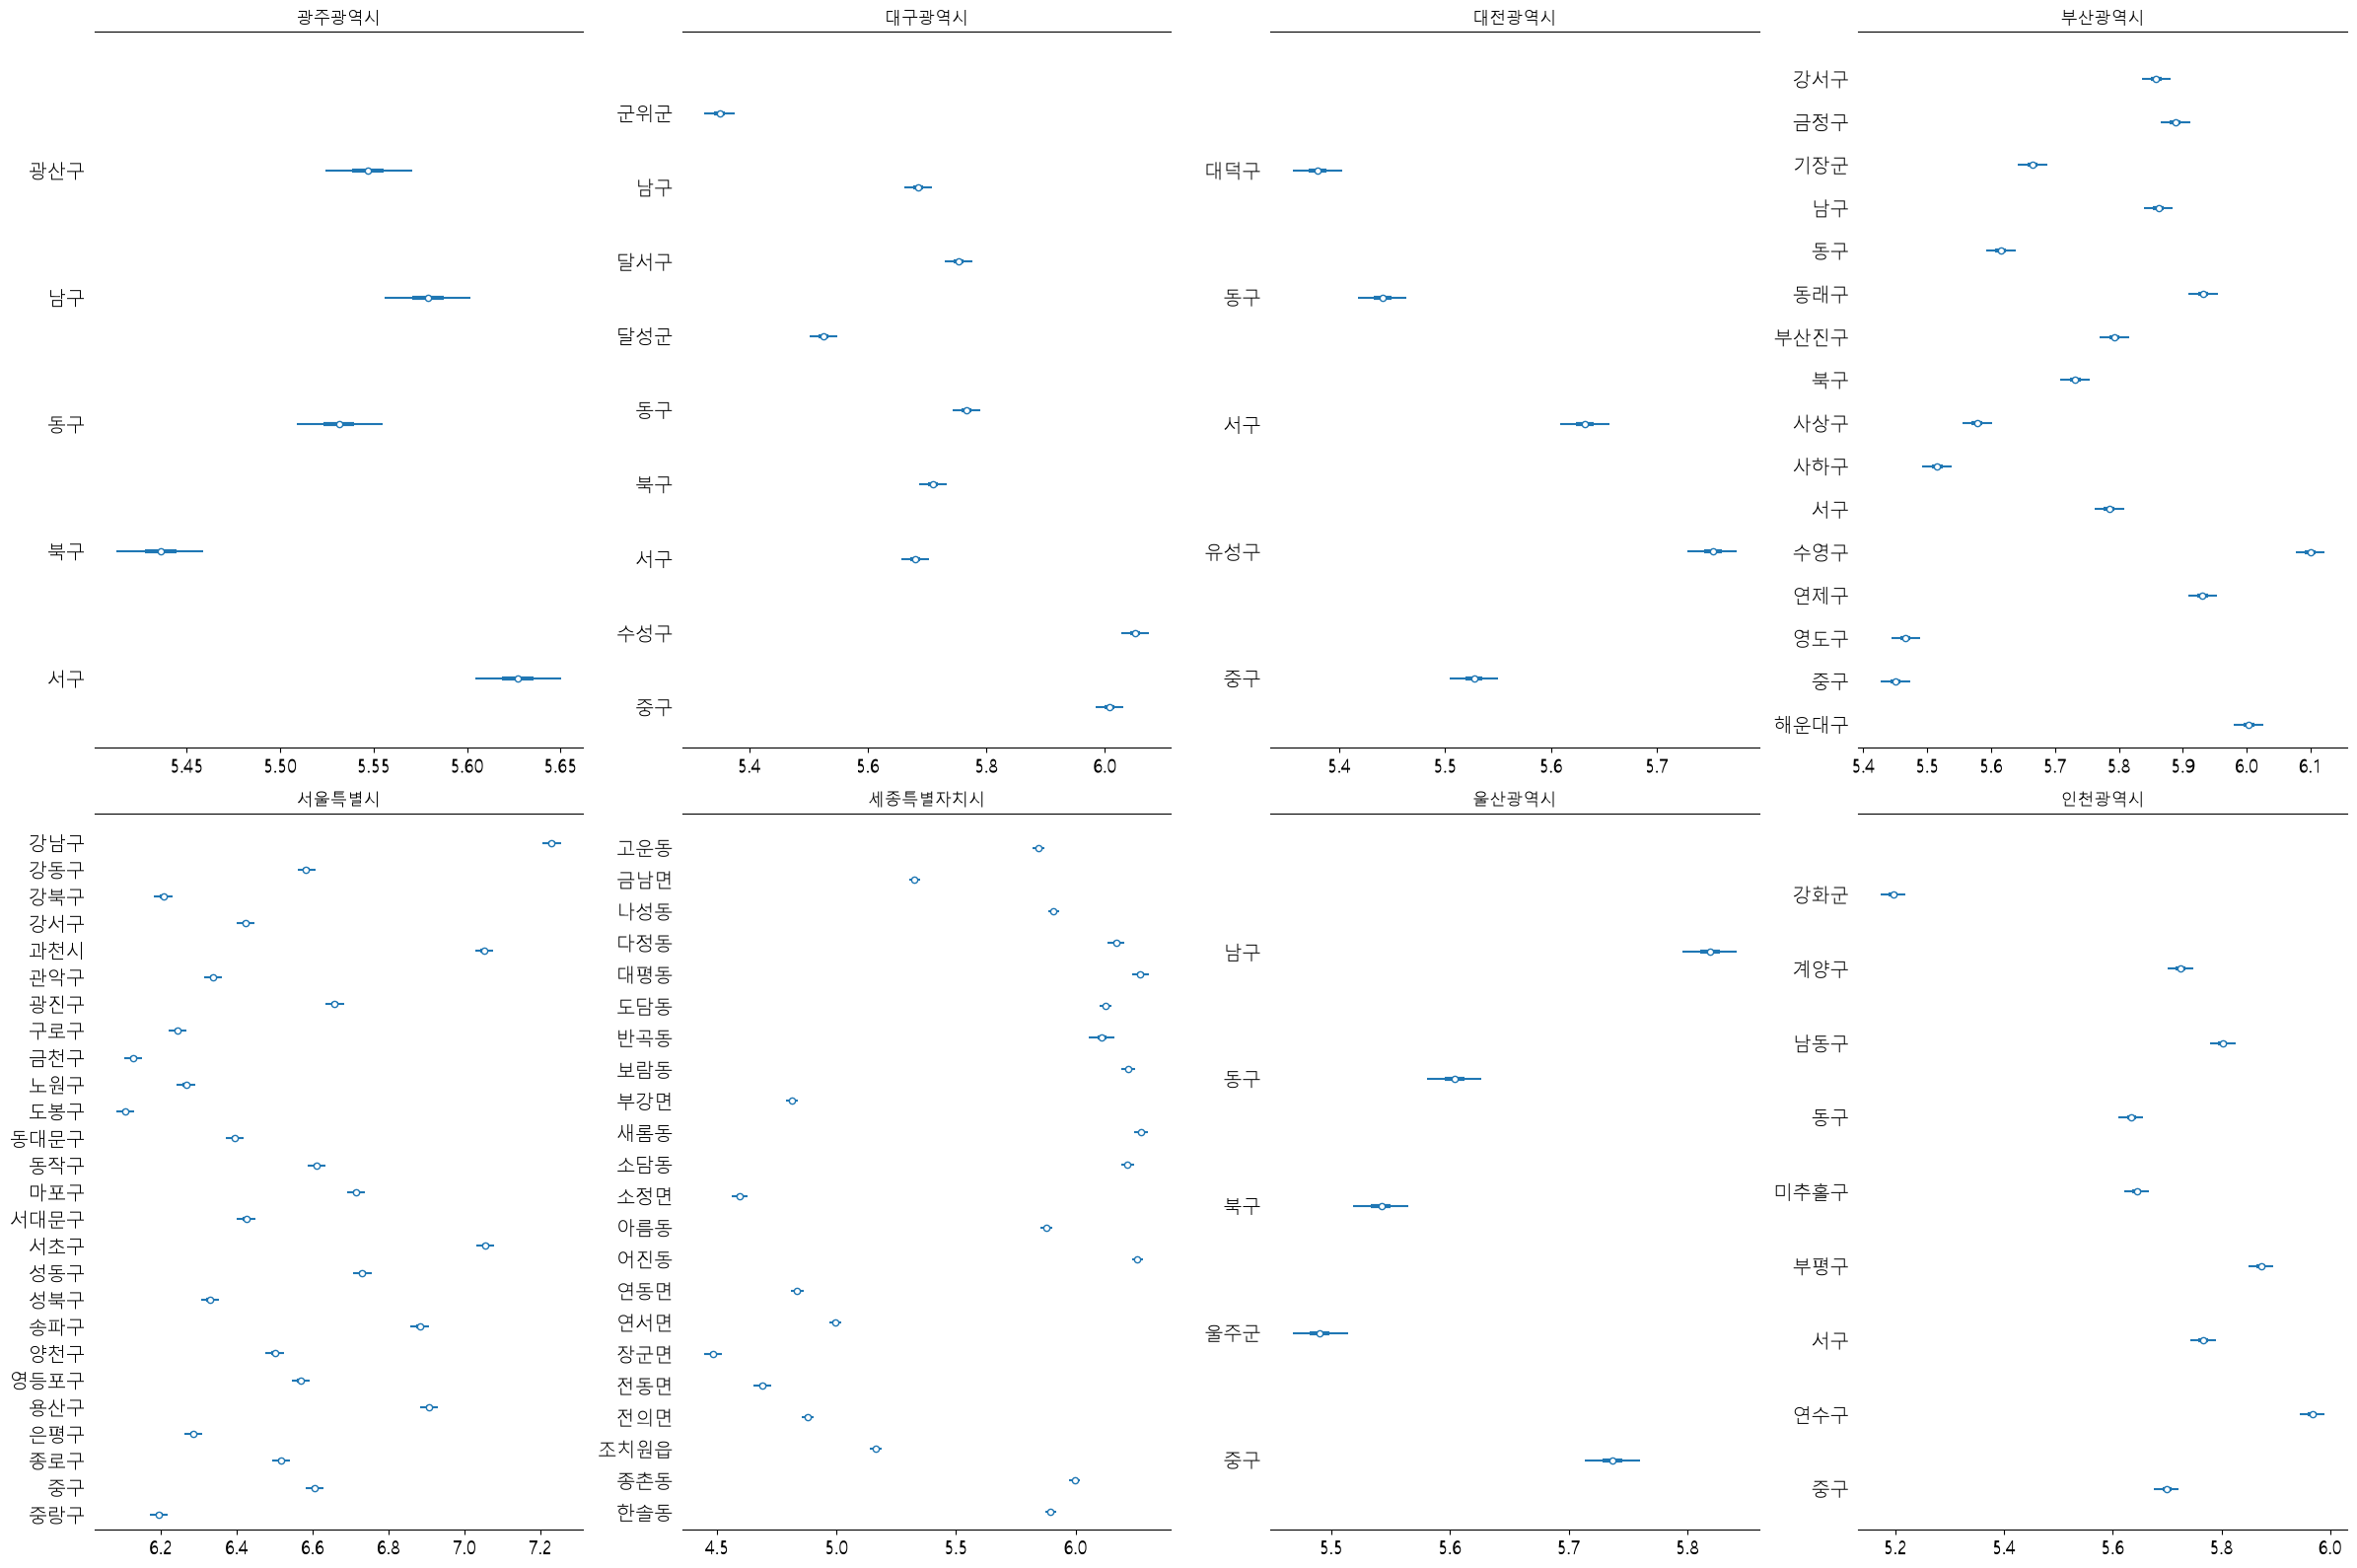

In [44]:
region_to_city = (
    df[['REGION_IDX', 'CITY_IDX']]
    .drop_duplicates()
    .sort_values('REGION_IDX')['CITY_IDX']
    .values
)

city_names = (
    df
    .drop_duplicates('CITY_IDX')
    .set_index('CITY_IDX')['CITY']
    .sort_index()
    .to_dict()
)
city_names = list(city_names.values())

region_names = (
    df
    .drop_duplicates('REGION_IDX')
    .set_index('REGION_IDX')['REGION']
    .sort_index()
    .to_dict()
)
region_names = list(region_names.values())
region_names = [name.split("_")[-1] for name in region_names]
region_names = np.array(region_names)

unique_cities = np.unique(region_to_city)

fig, axes = plt.subplots(
    nrows=2, 
    ncols=4, 
    figsize=(6*4, 8*2),
)

for ax, city in zip(axes.flatten(), unique_cities):
    region_idx = np.where(region_to_city==city)[0]

    az.plot_forest(
        data=trace,
        var_names=["alpha_region"],
        coords={"alpha_region_dim_0": region_idx},
        combined=True,
        ax=ax,
    )

    ax.set_yticklabels(region_names[region_idx][::-1])
    ax.set_title(city_names[city])

plt.tight_layout()
plt.show()

# Fixed Effect: Time

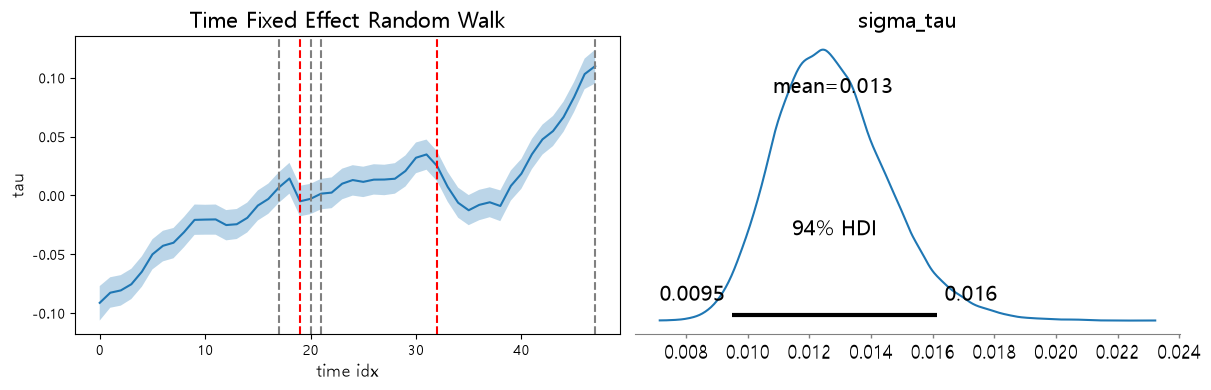

In [45]:
tau_posterior = trace.posterior["tau"]
tau_mean = tau_posterior.mean(dim=("chain", "draw"))
tau_hdi = az.hdi(tau_posterior)["tau"]

MAIN_POLICY = ["2017-08", "2018-09"]
ADDITIONAL_POLICY = ["2017-06", "2017-09", "2017-10", "2019-12"]

fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(6*2, 4),
)

axes = axes.flatten()

axes[0].plot(tau_mean)

axes[0].fill_between(
    x=range(len(tau_mean)),
    y1=tau_hdi.sel(hdi="lower"),
    y2=tau_hdi.sel(hdi="higher"),
    alpha=0.3,
)

for policy_date in MAIN_POLICY:
    policy_idx = df[df["YEARMONTH"]==policy_date]["TIME_IDX"].unique()[0]
    axes[0].axvline(policy_idx, color='red', linestyle='--')

for policy_date in ADDITIONAL_POLICY:
    policy_idx = df[df["YEARMONTH"]==policy_date]["TIME_IDX"].unique()[0]
    axes[0].axvline(policy_idx, color='gray', linestyle='--')

axes[0].set_xlabel("time idx", fontsize=12)
axes[0].set_ylabel("tau", fontsize=12)
axes[0].set_title("Time Fixed Effect Random Walk", fontsize=16)

az.plot_posterior(
    data=trace, 
    var_names=["sigma_tau"],
    ax=axes[1],
)

plt.tight_layout()
plt.show()

# Average Treatment Effect on the Treated

In [46]:
az.summary(
    data=trace, 
    var_names=["delta1", "delta2"],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta1,0.072,0.006,0.060,0.084,0.0,0.0,10269.0,18132.0,1.0
delta2,0.150,0.006,0.139,0.162,0.0,0.0,9529.0,17811.0,1.0


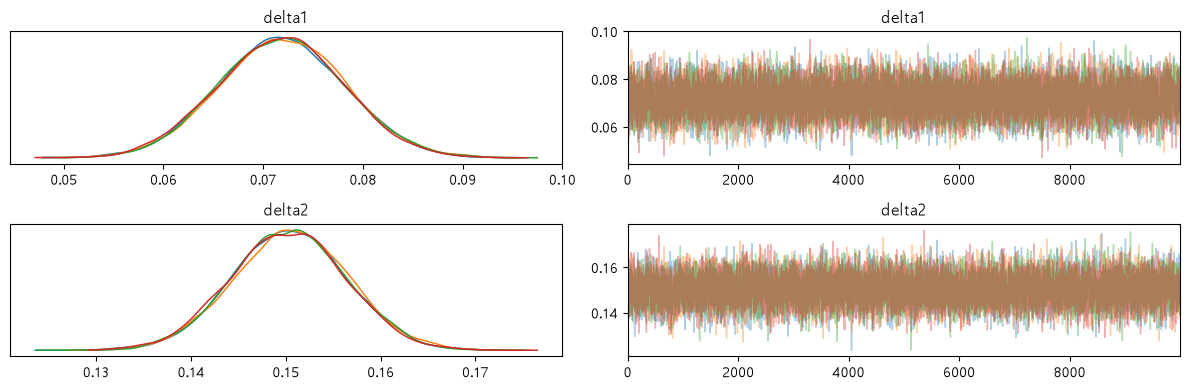

In [47]:
az.plot_trace(
    data=trace, 
    var_names=["delta1", "delta2"], 
    compact=False,
)
plt.tight_layout()
plt.show()

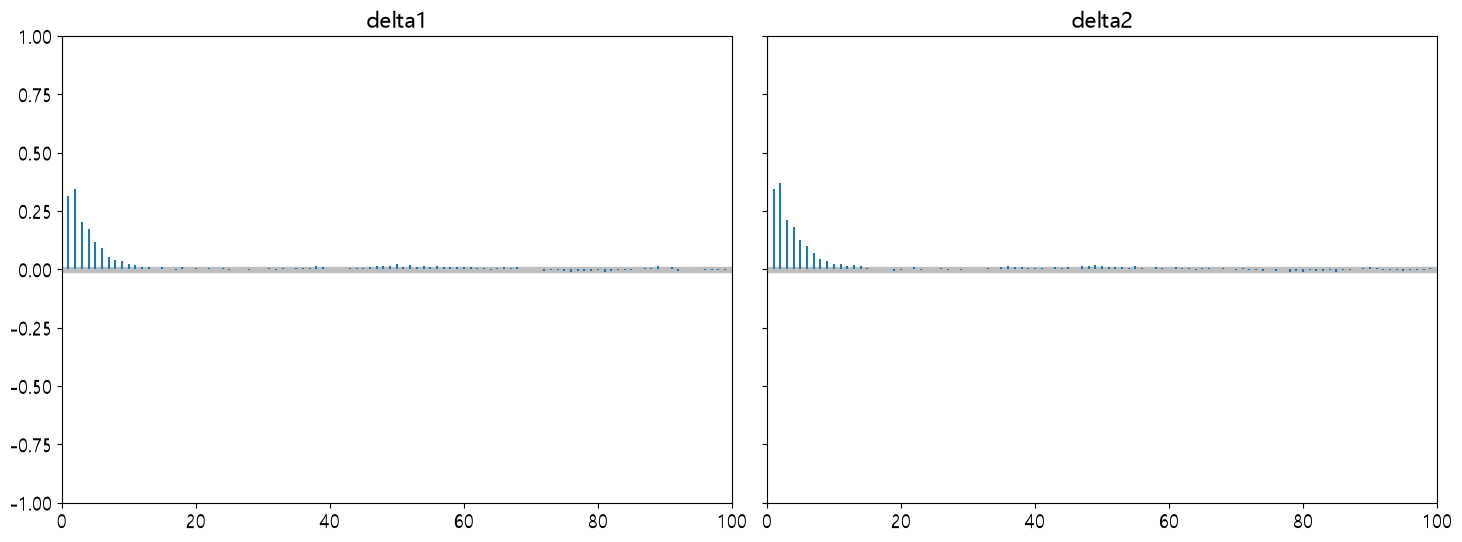

In [48]:
az.plot_autocorr(
    data=trace, 
    var_names=["delta1", "delta2"],
    combined=True,
)
plt.tight_layout()
plt.show()

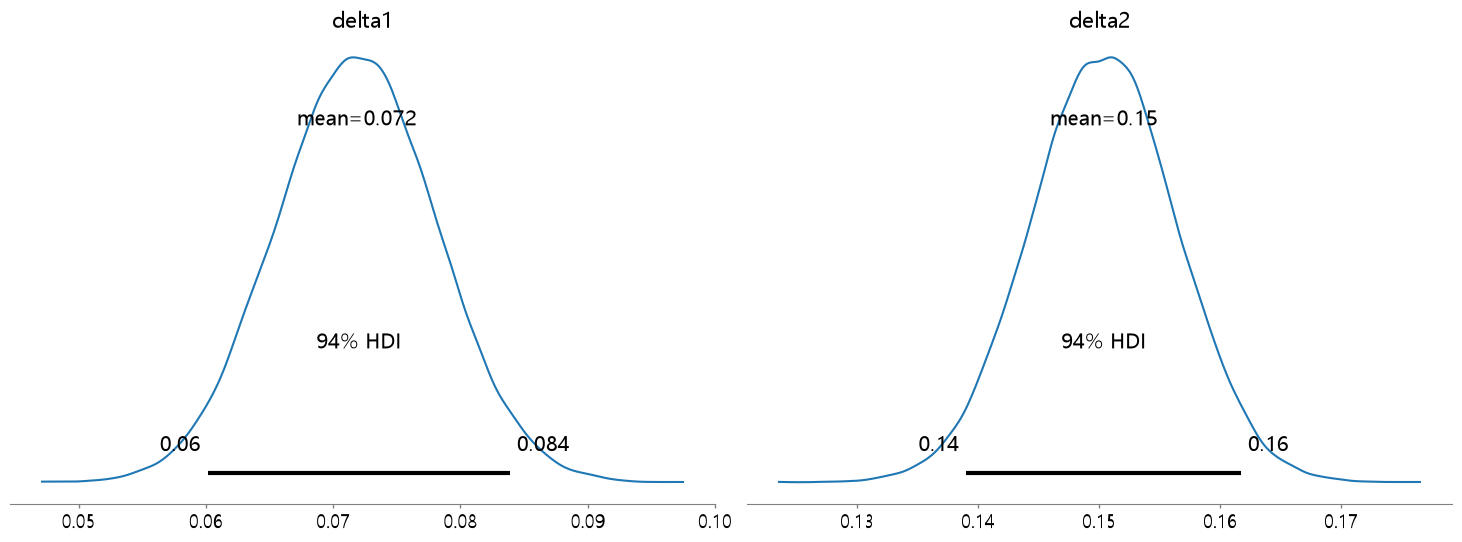

In [49]:
az.plot_posterior(
    data=trace, 
    var_names=["delta1", "delta2"],
)
plt.tight_layout()
plt.show()